# **NEURAL NETWORK**
# 1. Introduction
A neural network is a mathematical model that mimics the information transmission of the brain (nervous system).

# 2. MNIST Dataset
We will use the MNIST dataset to verify the neural network scratch. MNIST dataset is a popular dataset for image classification, for handwritten digit recognition. The dataset contains 60,000 training and 10,000 test 28x28 pixel black and white images, along with labels indicating which digits between 0 and 9 they are

A digital image is a collection of dots, called pixels. Generally, in black and white images, pixels contain values ​​from 0 to 255. On the other hand, in color images, pixels contain values ​​from 0 to 255 corresponding to R (red), G (green), and B (blue). In machine learning, each of these values ​​from 0 to 255 is treated as a feature. Since 0 to 255 is a range that can be represented by an unsigned 8-bit integer, in NumPy they can be stored as a variable of type "uint8".

In [1]:
# download the dataset
from keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

2025-04-22 03:38:56.255915: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745293136.492697      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745293136.561163      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [2]:
# check dataset
print(X_train.shape) # (60000, 28, 28)
print(X_test.shape) # (10000, 28, 28)
print(X_train[0].dtype) # uint8
print(X_train[0])

(60000, 28, 28)
(10000, 28, 28)
uint8
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0 

# Smoothing
Convert each image (1, 28, 28) to (1, 784). This is how it is handled in the machine learning methods we have learned so far and in the neural network with only fully connected layers we will be using this time. The fact that all the pixels are in a row is referred to as "flattening."

In [3]:
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

So far in our study of machine learning, we have referred to the number of features as "dimension." From this perspective, MNIST is 784-dimensional data. On the other hand, a NumPy shape of (784,) is also called a one-dimensional array. If it were in a (28, 28) state, which holds the length and width information of an image, it would be a two-dimensional array. From this perspective, it is two-dimensional data. Furthermore, if it were a color image, it would be (28, 28, 3), which would be a three-dimensional array. From the perspective above, it would be three-dimensional data. However, whether black and white or color, it is a flat image, not three-dimensional data, so it is two-dimensional data.

# Visualization of Image Data

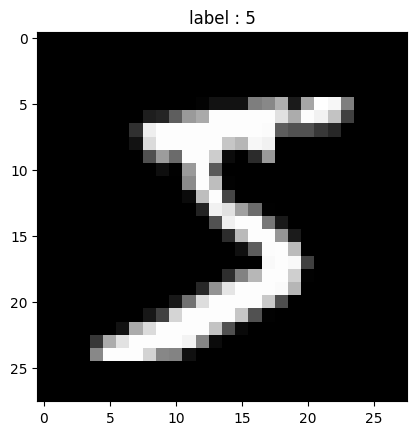

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline
index = 0
image = X_train[index].reshape(28,28)
# X_train[index]: (784,)
# image: (28, 28)
plt.imshow(image, 'gray')
plt.title('label : {}'.format(y_train[index]))
plt.show()

Image data is generally stored as an unsigned 8-bit integer uint8, but plt.imshowit is possible to display more flexible arrays as images. For example, even if a float64 type floating point number with a negative value is used as shown below, no error will occur and it will be displayed in exactly the same way as before.

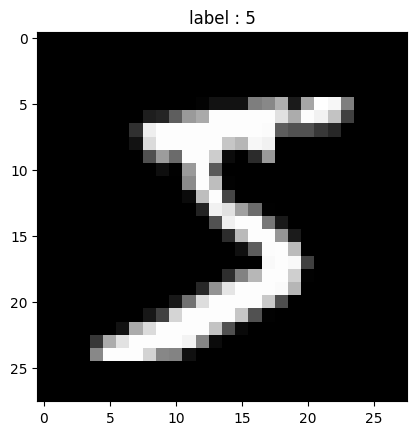

[[-105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35
  -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35
  -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35
  -105.35]
 [-105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35
  -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35
  -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35
  -105.35]
 [-105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35
  -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35
  -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35
  -105.35]
 [-105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35
  -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35
  -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35
  -105.35]
 [-105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -105.35 -1

In [5]:
import numpy as np
index = 0
image = X_train[index].reshape(28,28)
image = image.astype(np.float64) # Convert to float
image -= 105.35 # Intentionally creating negative decimals
plt.imshow(image, 'gray')
plt.title('label : {}'.format(y_train[index]))
plt.show()
print(image) # Check the value

This is because the value is automatically converted to an integer between 0 and 255 for processing. Even if the type is uint8, if the minimum value is not 0 and the maximum value is not 255, the color will be strange. To prevent this, enter the arguments as follows:

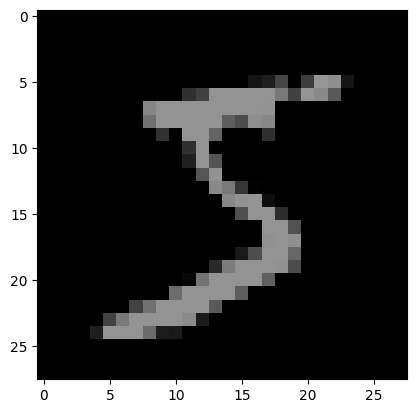

In [6]:
plt.imshow(image, 'gray', vmin = 0, vmax = 255)

# Pretreatment
Images are represented as uint8 type values ranging from 0 to 255, but for machine learning they are handled as float type values ranging from 0 to 1. The following code can be used to convert them.

In [7]:
X_train = X_train.astype(np.float64)
X_test = X_test.astype(np.float64)
X_train /= 255
X_test /= 255
print(X_train.max()) # 1.0
print(X_train.min()) # 0.0

1.0
0.0


Also, the correct label is an integer between 0 and 9, but when performing multi-class classification with a neural network, it is converted to a one-hot representationOneHotEncoder . Below is the code using scikit-learn. Since the value in this one-hot representation indicates the probability of that label, it is handled as a float type.

In [8]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
y_train_one_hot = enc.fit_transform(y_train[:, np.newaxis])
y_test_one_hot = enc.transform(y_test[:, np.newaxis])
print(y_train.shape) # (60000,)
print(y_train_one_hot.shape) # (60000, 10)
print(y_train_one_hot.dtype) # float64

(60000,)
(60000, 10)
float64


In addition, we split 20% of the 60,000 training data into validation data: 48,000 training data and 12,000 validation data.

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2)
print(X_train.shape) # (48000, 784)
print(X_val.shape) # (12000, 784)

(48000, 784)
(12000, 784)


In [10]:
print(X_train.shape)         # should be (48000, 784)
print(y_train_one_hot.shape) # should be (48000, 10)

(48000, 784)
(60000, 10)


In [11]:
# Trim to much length
min_len = min(len(X_train), len(y_train_one_hot))
X_train = X_train[:min_len]
y_train_one_hot = y_train_one_hot[:min_len]

In [12]:
min_len = min(len(X_test), len(y_test_one_hot))
X_test = X_test[:min_len]
y_test_one_hot = y_test_one_hot[:min_len]

# 3. Neural Network Scratch
We will create a neural network class from scratch. We will implement the algorithm using only a minimum number of libraries such as NumPy.

This time, we will create a three-layer neural network that performs multi-class classification. We will learn the basics of neural networks while fixing the number of layers. In the next Sprint, we will design it so that the layers can be freely changed.

# Mini-Batching
In neural networks, it is common to use the stochastic gradient descent method, which divides the data and inputs it. Each divided chunk is called a mini-batch, and the number of samples is called the batch size .

This time, we will use a batch size of 20. The training data used this time is 48,000 images, so 48,000 divided by 20 will result in 2,400 updates. In neural networks, this is called 2,400 iterations . Once all the training data has been seen once, one epoch is complete. This epoch is repeated multiple times to complete learning.

To achieve this, we provide a simple iterator that can be called in a for statement to get mini-batches:

In [13]:
class GetMiniBatch:

    def __init__(self, X, y, batch_size = 20, seed=0):
        self.batch_size = batch_size
        np.random.seed(seed)
        shuffle_index = np.random.permutation(np.arange(X.shape[0]))
        self._X = X[shuffle_index]
        self._y = y[shuffle_index]
        self._stop = int(np.ceil(X.shape[0] / self.batch_size))


    def __len__(self):
        return self._stop

    def __getitem__(self,item):
        p0 = item*self.batch_size
        p1 = item*self.batch_size + self.batch_size
        return self._X[p0:p1], self._y[p0:p1]        

    def __iter__(self):
        self._counter = 0
        return self

    def __next__(self):
        if self._counter >= self._stop:
            raise StopIteration()
        p0 = self._counter*self.batch_size
        p1 = self._counter*self.batch_size + self.batch_size
        self._counter += 1
        return self._X[p0:p1], self._y[p0:p1]

Extract mini-batches by instatiating this class and using a for statement.

In [14]:
get_mini_batch = GetMiniBatch(X_train, y_train, batch_size=20)

print(len(get_mini_batch)) # 2400
print(get_mini_batch[5]) # The fifth mini-batch is obtained.
for mini_X_train, mini_y_train in get_mini_batch:
    # use mini-batches in this for statement.
    pass

2400
(array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]]), array([7, 3, 1, 5, 0, 4, 2, 2, 9, 2, 2, 8, 5, 7, 0, 3, 2, 4, 2, 1],
      dtype=uint8))


Neural networks are trained by repeating forward propagation and backpropagation.
# Problem 1: Creating code to determine the initial weight values
We will determine the initial values of the weights in each layer of a neural network. There are many methods proposed for initializing the weights, but here we will use a simple Gaussian distribution. The same goes for the bias.

In [15]:
class ScratchSimpleNeuralNetrowkClassifier: # class definition

    def __init__(self, n_features=784, n_nodes1=400, n_nodes2=200, n_output=10, sigma=0.01): # constructor definition
        self.n_features = n_features
        self.n_nodes1 = n_nodes1
        self.n_nodes2 = n_nodes2
        self.n_output = n_output
        self.sigma = sigma

        # Weight initialize
        self.W1 = self.sigma * np.random.randn(self.n_features, self.n_nodes1)
        self.W2 = self.sigma * np.random.randn(self.n_nodes1, self.n_nodes2)
        self.W3 = self.sigma * np.random.randn(self.n_nodes2, self.n_output)

        # Bias initialize
        self.B1 = self.sigma * np.random.randn(1, self.n_nodes1)
        self.B2 = self.sigma * np.random.randn(1, self.n_nodes2)
        self.B3 = self.sigma * np.random.randn(1, self.n_output)
initialize = ScratchSimpleNeuralNetrowkClassifier()
print(initialize.W1.shape) 
print(initialize.B1.shape) 
print(initialize.W2.shape) 
print(initialize.B2.shape)
print(initialize.W3.shape) 
print(initialize.B3.shape) 

(784, 400)
(1, 400)
(400, 200)
(1, 200)
(200, 10)
(1, 10)


# Problem 2: Implementing forward propagation
We will a three-layered forward propagation neural network. In the following explanation, the number of nodes is 400 in the first layer and 200 in the second layer.

The formulas for each layer are shown below. This time, we also show what ndarray shape each symbol represents in the implementation.

In [16]:
import numpy as np

class ScratchSimpleNeuralNetrowkClassifier:
    def __init__(self, n_features=784, n_nodes1=400, n_nodes2=200, n_output=10, sigma=0.01):
        self.n_features = n_features
        self.n_nodes1 = n_nodes1
        self.n_nodes2 = n_nodes2
        self.n_output = n_output
        self.sigma = sigma

        # Weight initialization
        self.W1 = self.sigma * np.random.randn(n_features, n_nodes1)
        self.B1 = self.sigma * np.random.randn(1, n_nodes1)

        self.W2 = self.sigma * np.random.randn(n_nodes1, n_nodes2)
        self.B2 = self.sigma * np.random.randn(1, n_nodes2)

        self.W3 = self.sigma * np.random.randn(n_nodes2, n_output)
        self.B3 = self.sigma * np.random.randn(1, n_output)

    def tanh_function(self, x):
        return np.tanh(x)

    def softmax(self, x):
        # Shift max for numerical stability
        x_shifted = x - np.max(x, axis=1, keepdims=True)
        exp_x = np.exp(x_shifted)
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def forward(self, X):
        # Layer 1
        self.A1 = X @ self.W1 + self.B1
        self.Z1 = self.tanh_function(self.A1)

        # Layer 2
        self.A2 = self.Z1 @ self.W2 + self.B2
        self.Z2 = self.tanh_function(self.A2)

        # Output Layer
        self.A3 = self.Z2 @ self.W3 + self.B3
        self.Z3 = self.softmax(self.A3)

        return self.Z3
        
    def sigmoid(self,X):
        result = 1 / (1 + np.exp(-X)) 
        return result

    def tanh(self,X):
        result = (np.exp(X)-np.exp(-X))/(np.exp(X)+np.exp(-X))
    # or
    #  result = np.tanh(X)
        return result

    
    def softmax(self,X):
        result = np.exp(X) / np.sum(np.exp(X), axis=1, keepdims=True)
        return result

# Problem 3: Implementing cross-entropy error
We create an objective function (loss function).

In [17]:
import numpy as np

class ScratchSimpleNeuralNetrowkClassifier:
    def __init__(self, n_features=784, n_nodes1=400, n_nodes2=200, n_output=10, sigma=0.01):
        self.n_features = n_features
        self.n_nodes1 = n_nodes1
        self.n_nodes2 = n_nodes2
        self.n_output = n_output
        self.sigma = sigma

        # Weight initialization
        self.W1 = self.sigma * np.random.randn(n_features, n_nodes1)
        self.B1 = self.sigma * np.random.randn(1, n_nodes1)

        self.W2 = self.sigma * np.random.randn(n_nodes1, n_nodes2)
        self.B2 = self.sigma * np.random.randn(1, n_nodes2)

        self.W3 = self.sigma * np.random.randn(n_nodes2, n_output)
        self.B3 = self.sigma * np.random.randn(1, n_output)

    def tanh_function(self, x):
        return np.tanh(x)

    def softmax(self, x):
        # Shift max for numerical stability
        x_shifted = x - np.max(x, axis=1, keepdims=True)
        exp_x = np.exp(x_shifted)
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def forward(self, X):
        # Layer 1
        self.A1 = X @ self.W1 + self.B1
        self.Z1 = self.tanh_function(self.A1)

        # Layer 2
        self.A2 = self.Z1 @ self.W2 + self.B2
        self.Z2 = self.tanh_function(self.A2)

        # Output Layer
        self.A3 = self.Z2 @ self.W3 + self.B3
        self.Z3 = self.softmax(self.A3)

        return self.Z3
        
    def sigmoid(self,X):
        result = 1 / (1 + np.exp(-X)) 
        return result

    def tanh(self,X):
        result = (np.exp(X)-np.exp(-X))/(np.exp(X)+np.exp(-X))
    # or
    #  result = np.tanh(X)
        return result

    
    def softmax(self,X):
        result = np.exp(X) / np.sum(np.exp(X), axis=1, keepdims=True)
        return result
    def cross_entropy_error(self, y, Z):
        L = - np.sum(y * np.log(Z+1e-7)) / len(y) # add np.logto the calculation of to avoid errors
        return L

# Problem 4: Implementing backpropagation
We create a three-layer backpropagation neural network, this is the part that performs stochastic gradient descent.

In [18]:
import numpy as np

class ScratchSimpleNeuralNetrowkClassifier:
    def __init__(self, n_features=784, n_nodes1=400, n_nodes2=200, n_output=10, sigma=0.01):
        self.n_features = n_features
        self.n_nodes1 = n_nodes1
        self.n_nodes2 = n_nodes2
        self.n_output = n_output
        self.sigma = sigma

        # Weight initialization
        self.W1 = self.sigma * np.random.randn(n_features, n_nodes1)
        self.B1 = self.sigma * np.random.randn(1, n_nodes1)

        self.W2 = self.sigma * np.random.randn(n_nodes1, n_nodes2)
        self.B2 = self.sigma * np.random.randn(1, n_nodes2)

        self.W3 = self.sigma * np.random.randn(n_nodes2, n_output)
        self.B3 = self.sigma * np.random.randn(1, n_output)

    def tanh_function(self, x):
        return np.tanh(x)

    def softmax(self, x):
        # Shift max for numerical stability
        x_shifted = x - np.max(x, axis=1, keepdims=True)
        exp_x = np.exp(x_shifted)
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def forward(self, X):
        # Layer 1
        self.A1 = X @ self.W1 + self.B1
        self.Z1 = self.tanh_function(self.A1)

        # Layer 2
        self.A2 = self.Z1 @ self.W2 + self.B2
        self.Z2 = self.tanh_function(self.A2)

        # Output Layer
        self.A3 = self.Z2 @ self.W3 + self.B3
        self.Z3 = self.softmax(self.A3)

        return self.Z3
        
    def sigmoid(self,X):
        result = 1 / (1 + np.exp(-X)) 
        return result

    def tanh(self,X):
        result = (np.exp(X)-np.exp(-X))/(np.exp(X)+np.exp(-X))
    # or
    #  result = np.tanh(X)
        return result

    
    def softmax(self,X):
        result = np.exp(X) / np.sum(np.exp(X), axis=1, keepdims=True)
        return result
    def cross_entropy_error(self, y, Z):
        L = - np.sum(y * np.log(Z+1e-7)) / len(y) # add np.logto the calculation of to avoid errors
        return L
        
    def backward(self, X, y):
        # Outer layer gradient
        dA3 = (self.Z3 - y)/self.batch_size
        dW3 = self.Z2.T @ dA3
        dB3 = np.sum(dA3, axis=0)
        # Second layer gradient
        dZ2 = dA3 @ self.W3.T
        dA2 = dZ2 * (1 - self.tanh_function(self.A2)**2)
        dW2 = self.Z1.T @ dA2
        dB2 = np.sum(dA2, axis=0)
        # First layer gradient
        dZ1 = dA2 @ self.W2.T
        dA1 = dZ1 * (1 - self.tanh_function(self.A1)**2)
        dW1 = X.T @ dA1
        dB1 = np.sum(dA1, axis=0)
        # Update weights and biases
        self.W3 -= self.lr * dW3
        self.B3 -= self.lr * dB3
        self.W2 -= self.lr * dW2
        self.B2 -= self.lr * dB2
        self.W1 -= self.lr * dW1
        self.B1 -= self.lr * dB1

# Problem 5: Estimation


def predict(self, X):
    self.forward(X)
    return np.argmax(self.Z3, axis=1)

In [19]:
import numpy as np

class ScratchSimpleNeuralNetrowkClassifier:
    def __init__(self, n_features=784, n_nodes1=400, n_nodes2=200, n_output=10, sigma=0.01):
        self.n_features = n_features
        self.n_nodes1 = n_nodes1
        self.n_nodes2 = n_nodes2
        self.n_output = n_output
        self.sigma = sigma

        # Weight initialization
        self.W1 = self.sigma * np.random.randn(n_features, n_nodes1)
        self.B1 = self.sigma * np.random.randn(1, n_nodes1)

        self.W2 = self.sigma * np.random.randn(n_nodes1, n_nodes2)
        self.B2 = self.sigma * np.random.randn(1, n_nodes2)

        self.W3 = self.sigma * np.random.randn(n_nodes2, n_output)
        self.B3 = self.sigma * np.random.randn(1, n_output)

    def tanh_function(self, x):
        return np.tanh(x)

    def softmax(self, x):
        # Shift max for numerical stability
        x_shifted = x - np.max(x, axis=1, keepdims=True)
        exp_x = np.exp(x_shifted)
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def forward(self, X):
        # Layer 1
        self.A1 = X @ self.W1 + self.B1
        self.Z1 = self.tanh_function(self.A1)

        # Layer 2
        self.A2 = self.Z1 @ self.W2 + self.B2
        self.Z2 = self.tanh_function(self.A2)

        # Output Layer
        self.A3 = self.Z2 @ self.W3 + self.B3
        self.Z3 = self.softmax(self.A3)

        return self.Z3
        
    def sigmoid(self,X):
        result = 1 / (1 + np.exp(-X)) 
        return result

    def tanh(self,X):
        result = (np.exp(X)-np.exp(-X))/(np.exp(X)+np.exp(-X))
    # or
    #  result = np.tanh(X)
        return result

    
    def softmax(self,X):
        result = np.exp(X) / np.sum(np.exp(X), axis=1, keepdims=True)
        return result
    def cross_entropy_error(self, y, Z):
        L = - np.sum(y * np.log(Z+1e-7)) / len(y) # add np.logto the calculation of to avoid errors
        return L

    def backward(self, X, y):
        # Outer layer gradient
        dA3 = (self.Z3 - y)/self.batch_size
        dW3 = self.Z2.T @ dA3
        dB3 = np.sum(dA3, axis=0)
        # Second layer gradient
        dZ2 = dA3 @ self.W3.T
        dA2 = dZ2 * (1 - self.tanh_function(self.A2)**2)
        dW2 = self.Z1.T @ dA2
        dB2 = np.sum(dA2, axis=0)
        # First layer gradient
        dZ1 = dA2 @ self.W2.T
        dA1 = dZ1 * (1 - self.tanh_function(self.A1)**2)
        dW1 = X.T @ dA1
        dB1 = np.sum(dA1, axis=0)
        # Update weights and biases
        self.W3 -= self.lr * dW3
        self.B3 -= self.lr * dB3
        self.W2 -= self.lr * dW2
        self.B2 -= self.lr * dB2
        self.W1 -= self.lr * dW1
        self.B1 -= self.lr * dB1
    def predict(self, X):
        self.forward(X)
        return np.argmax(self.Z3, axis=1)
            

# 4. Verification
# Problem 6: Learning and estimation
Train and estimate the MNIST data and calculate the accuracy.

In [20]:
class GetMiniBatch:

    def __init__(self, X, y, batch_size = 20, seed=0):
        self.batch_size = batch_size
        np.random.seed(seed)
        shuffle_index = np.random.permutation(np.arange(X.shape[0]))
        self._X = X[shuffle_index]
        self._y = y[shuffle_index]
        self._stop = int(np.ceil(X.shape[0] / self.batch_size))


    def __len__(self):
        return self._stop

    def __getitem__(self,item):
        p0 = item*self.batch_size
        p1 = item*self.batch_size + self.batch_size
        return self._X[p0:p1], self._y[p0:p1]        

    def __iter__(self):
        self._counter = 0
        return self

    def __next__(self):
        if self._counter >= self._stop:
            raise StopIteration()
        p0 = self._counter*self.batch_size
        p1 = self._counter*self.batch_size + self.batch_size
        self._counter += 1
        return self._X[p0:p1], self._y[p0:p1]
        
class ScratchSimpleNeuralNetrowkClassifier:
    def __init__(self, batch_size = 20,n_features = 784,n_nodes1 = 400,n_nodes2 = 200,n_output = 10,sigma = 0.02,lr = 0.01,epoch = 10, verbose=True):
        self.verbose = verbose # Member variableization of arguments
        self.batch_size = batch_size
        self.n_features = n_features
        self.n_nodes1 = n_nodes1
        self.n_nodes2 = n_nodes2
        self.n_output = n_output
        self.sigma = sigma
        self.lr = lr
        self.epoch = epoch
        self.loss_train = [] # Variable definition for storing loss
        self.loss_val = []

        # Weight initialization
        self.W1 = self.sigma * np.random.randn(n_features, n_nodes1)
        self.B1 = self.sigma * np.random.randn(1, n_nodes1)

        self.W2 = self.sigma * np.random.randn(n_nodes1, n_nodes2)
        self.B2 = self.sigma * np.random.randn(1, n_nodes2)

        self.W3 = self.sigma * np.random.randn(n_nodes2, n_output)
        self.B3 = self.sigma * np.random.randn(1, n_output)

    def tanh_function(self, x):
        return np.tanh(x)

    def softmax(self, x):
        # Shift max for numerical stability
        x_shifted = x - np.max(x, axis=1, keepdims=True)
        exp_x = np.exp(x_shifted)
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def forward(self, X):
        # Layer 1
        self.A1 = X @ self.W1 + self.B1
        self.Z1 = self.tanh_function(self.A1)

        # Layer 2
        self.A2 = self.Z1 @ self.W2 + self.B2
        self.Z2 = self.tanh_function(self.A2)

        # Output Layer
        self.A3 = self.Z2 @ self.W3 + self.B3
        self.Z3 = self.softmax(self.A3)

        return self.Z3
        
    def sigmoid(self,X):
        result = 1 / (1 + np.exp(-X)) 
        return result

    def tanh(self,X):
        result = (np.exp(X)-np.exp(-X))/(np.exp(X)+np.exp(-X))
    # or
    #  result = np.tanh(X)
        return result

    def identity_function(self,X):
        return X
    
    def relu(self,X):
        result = np.max([np.zeros(X.shape), X], axis=0)   
        return result
    
    def step_function(self,X):
        result = np.array(X >= 0, dtype=np.int)
        return result
    
    def softmax(self,X):
        result = np.exp(X) / np.sum(np.exp(X), axis=1, keepdims=True)
        return result
    def cross_entropy_error(self, y, Z):
        L = - np.sum(y * np.log(Z+1e-7)) / len(y) # add np.logto the calculation of to avoid errors
        return L

    def backward(self, X, y):
        # Outer layer gradient
        dA3 = (self.Z3 - y)/self.batch_size
        dW3 = self.Z2.T @ dA3
        dB3 = np.sum(dA3, axis=0)
        # Second layer gradient
        dZ2 = dA3 @ self.W3.T
        dA2 = dZ2 * (1 - self.tanh_function(self.A2)**2)
        dW2 = self.Z1.T @ dA2
        dB2 = np.sum(dA2, axis=0)
        # First layer gradient
        dZ1 = dA2 @ self.W2.T
        dA1 = dZ1 * (1 - self.tanh_function(self.A1)**2)
        dW1 = X.T @ dA1
        dB1 = np.sum(dA1, axis=0)
        # Update weights and biases
        self.W3 -= self.lr * dW3
        self.B3 -= self.lr * dB3
        self.W2 -= self.lr * dW2
        self.B2 -= self.lr * dB2
        self.W1 -= self.lr * dW1
        self.B1 -= self.lr * dB1
        
    def predict(self, X):
        self.forward(X)
        return np.argmax(self.Z3, axis=1)  
                
    def fit(self, X, y, X_val=None, y_val=None):
        self.loss_train = []
        self.loss_val = []

        for epoch in range(self.epoch):
            get_mini_batch = GetMiniBatch(X, y, batch_size=self.batch_size)
            for mini_X_train, mini_y_train in get_mini_batch:
                self.forward(mini_X_train)
                self.backward(mini_X_train, mini_y_train)

            # Calculate full training loss after one epoch
            Z_train = self.forward(X)
            self.loss_train.append(self.cross_entropy_error(y, Z_train))


            # Calculate validation loss if validation data is provided
            if X_val is not None and y_val is not None:
                Z_val = self.forward(X_val)
                self.loss_val.append(self.cross_entropy_error(y_val, Z_val))


            # Print losses per epoch if verbose is enabled
            if self.verbose:
                print(f"Epoch {epoch+1} loss: train = {self.loss_train[-1]:.4f}", end="")
                if X_val is not None:
                    print(f", val = {self.loss_val[-1]:.4f}")
                else:
                    print()


In [21]:
# Creating a learning implementation
nn = ScratchSimpleNeuralNetrowkClassifier(epoch=10, batch_size=20, lr=0.01, verbose=True)
nn.fit(X_train,y_train_one_hot, X_test, y_test_one_hot)

Epoch 1 loss: train = 2.3006, val = 2.3049
Epoch 2 loss: train = 2.3000, val = 2.3059
Epoch 3 loss: train = 2.2995, val = 2.3067
Epoch 4 loss: train = 2.2990, val = 2.3072
Epoch 5 loss: train = 2.2985, val = 2.3076
Epoch 6 loss: train = 2.2981, val = 2.3079
Epoch 7 loss: train = 2.2976, val = 2.3081
Epoch 8 loss: train = 2.2971, val = 2.3083
Epoch 9 loss: train = 2.2965, val = 2.3087
Epoch 10 loss: train = 2.2960, val = 2.3091


In [22]:
# Accuracy Calculation
from sklearn.metrics import accuracy_score
pred_train = nn.predict(X_train)
train_acc = accuracy_score(y_train, pred_train)

pred_val = nn.predict(X_val)
val_acc = accuracy_score(y_val, pred_val)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

Train Accuracy: 0.1018
Validation Accuracy: 0.0977


# Problem 7: Plotting the learning curve
Plot the learning curve.

Neural networks are prone to overfitting, so it is important to check the learning curve. We should be able to record the loss (cross entropy error) per epoch on the training and validation data.

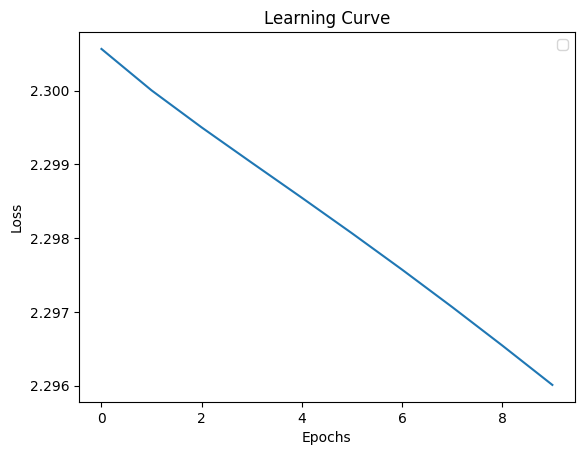

In [23]:
import matplotlib.pyplot as plt
plt.plot(range(nn.epoch), nn.loss_train)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Learning Curve")
plt.legend()
plt.grid(False)
plt.show()

# Problem 8: (Advanced task) Confirmation of misclassification
To see what the misclassified images were, prepare the estimates and run the following code:

In [24]:
y_pred = pred_val

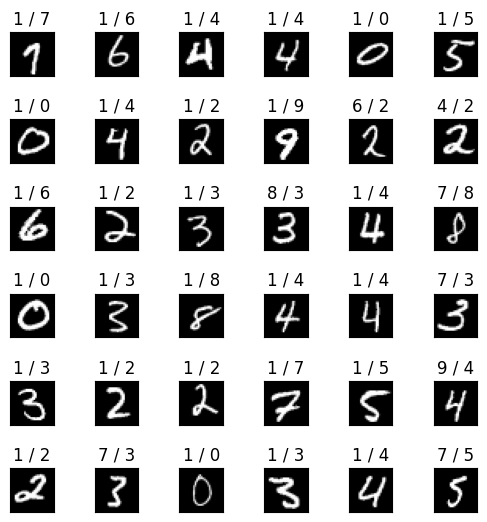

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def show_misclassified_images(y_pred, y_val, X_val, num=36):

    # Identify misclassified images
    true_false = y_pred == y_val
    false_list = np.where(true_false == False)[0].astype(int)

    # Ensure we display the specified misclassified images
    if false_list.shape[0] < num:
        num = false_list.shape[0]

    # Create a figure of the images
    fig = plt.figure(figsize=(6, 6))
    fig.subplots_adjust(left=0, right=0.8, bottom=0, top=0.8, hspace=1, wspace=0.5)

    # Loop through misclassified images and plot
    for i in range(num):
        ax = fig.add_subplot(6, 6, i + 1, xticks=[], yticks=[])
        ax.set_title(f"{y_pred[false_list[i]]} / {y_val[false_list[i]]}")
        ax.imshow(X_val[false_list[i]].reshape(28, 28), cmap='gray')

    plt.show()

# Example usage (assuming y_pred, y_val, and X_val are defined):
show_misclassified_images(y_pred, y_val, X_val, num=36)
